In [98]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [99]:
data_path = "OneDrive_3_10-3-2025"

In [100]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [101]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 3-16 to 3-22-25 (45326, 8)
2 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 3-30 to 4-5-25 (45072, 8)
3 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-13 to 4-19-25 (41088, 8)
4 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-20 to 4-26-25 (46686, 8)
5 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-27 to 5-3-25 (44169, 8)
6 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-6 to 4-12-25 (46630, 8)
7 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-11 to 5-17-25 (43268, 8)
8 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-18 to 5-24-25 (45104, 8)
9 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-25 to 5-31-25 (36851, 8)
10 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-4 to 5-10-25 (43955, 8)
11 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 6-1 to 6-7-25 (44523, 8)
12 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 6-15 to 6-21-25 (37234, 8)
13 CAR - EP, Flow, Activity, Queue, &amp; A

In [102]:
df_main['Activity Start Timestamp'] = pd.to_datetime(df_main['Activity Start Timestamp'], errors='coerce')

In [103]:
# Basic overview of 'EP Name' values
df_main['EP Name'].value_counts(dropna=False)

EP Name
Main Number Telephony EP                    445983
NaN                                         312347
Legal Menu Telephony EP                      92192
Pre-Legal Menu Seniors Menu Telephony EP     87087
Closed Queue Menu Telephony EP               62244
All LAC Queues Telephony EP                  54574
Courtesy Callback Telephony EP               38286
Closed Hours-Holidays Menu Telephony EP      27779
Other Legal Menu Telephony EP                27763
Legal Housing Menu Telephony EP              26564
Intake Outdial EP                            22741
Farmworker Main Number Telephony EP          22363
Legal Family Menu Telephony EP               22321
Legal Benefits Menu Telephony EP              3081
Legal HIV Menu Telephony EP                   2875
Legal Immigration Menu Telephony EP           2630
Legal Employment Menu Telephony EP            2250
Name: count, dtype: int64

In [104]:
# Create a smaller DataFrame for only Benefits Menu data
df_benefits_only = df_main[df_main['EP Name'] == 'Legal Benefits Menu Telephony EP'].copy()

In [105]:
# Step 1: Get all unique Contact Session IDs that went through the Benefits menu
benefits_sessions = df_benefits_only['Contact Session ID'].unique()

# Step 2: Filter df_main to only include those same sessions
df_benefits_fullpath = df_main[df_main['Contact Session ID'].isin(benefits_sessions)].copy()

# Step 3: sort chronologically to see the call flow order
df_benefits = df_benefits_fullpath.sort_values(
    by=['Contact Session ID', 'Activity Start Timestamp']
).reset_index(drop=True)

In [106]:
import numpy as np

# Sort by Contact Session ID and timestamp so "last" is truly the most recent
df_benefits = df_benefits.sort_values(by=['Contact Session ID', 'Activity Start Timestamp'])

# Identify the last EP Name per Contact Session ID
last_ep = (
    df_benefits.groupby('Contact Session ID')['EP Name']
    .last()
    .reset_index()
    .rename(columns={'EP Name': 'Last_EP_Name'})
)

# Merge that back to the main df_benefits
df_benefits = df_benefits.merge(last_ep, on='Contact Session ID', how='left')

# Create Yes/No or 1/0 indicator
df_benefits['Ended_in_Benefits_EP'] = np.where(
    df_benefits['Last_EP_Name'] == 'Legal Benefits Menu Telephony EP', 'Yes', 'No'
)

In [107]:
df_benefits['Contact Session ID'].nunique()

2451

In [116]:
# For each Contact Session ID, take the last non-null Activity Name
df_benefits['Last_NonNull_Activity'] = (
    df_benefits
      .groupby('Contact Session ID')['Activity Name']
      .transform(lambda s: s.dropna().iloc[-1] if s.notna().any() else np.nan)
)

In [128]:
# 1) Get unique Contact Session ID + their last non-null activity
last_activity_per_session = (
    df_benefits[['Contact Session ID', 'Last_NonNull_Activity']]
    .drop_duplicates(subset='Contact Session ID')
)

# 2) Count how many sessions ended in each activity
activity_end_counts = (
    last_activity_per_session['Last_NonNull_Activity']
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={'index': 'Activity Name', 'Last_NonNull_Activity': 'Unique Contact Sessions'})
)

In [142]:
activity_end_counts

,Unique Contact Sessions,count
0,ClosedQueueMenu,1529
1,LegalServerScreenPop,304
2,ClinicVoicemailTransfer,258
3,BenefitsMenu,102
4,DisconnectContact1,101
5,VeteransBenefitsVoicemailTransfer,64
6,QueueMenu1,24
7,PlayMOH300s,16
8,LegalMenu2,14
9,ScreenPopProcessComplete,12


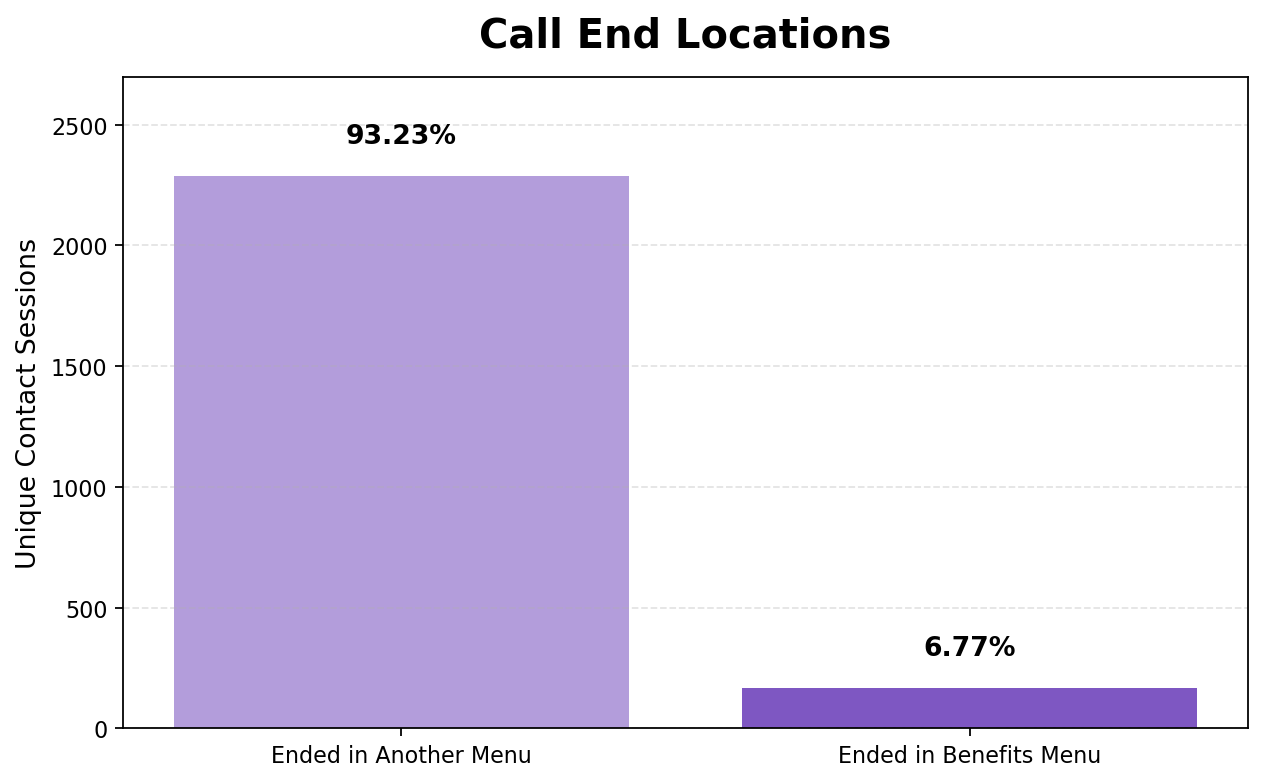

In [173]:
import matplotlib.pyplot as plt

max_count = grouped_counts['count'].max()
total = grouped_counts['count'].sum()

plt.figure(figsize=(8, 5), dpi=160)
bars = plt.bar(
    grouped_counts['Group'],
    grouped_counts['count'],
    color=['#B39DDB', '#7E57C2'],
    edgecolor='none'
)

# give extra space above the tallest bar
plt.ylim(0, max_count * 1.18)

# percent labels with bigger offset
for bar, pct in zip(bars, grouped_counts['percent']):
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + max_count * 0.05,          # <-- more padding
        f'{pct:.2f}%',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

plt.title('Call End Locations', fontsize=18, fontweight='bold', pad=14)
plt.ylabel('Unique Contact Sessions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()



In [171]:
# Filter for calls that ended in either BenefitsMenu or VeteransBenefitsVoicemailTransfer
df_benefits_ended = df_benefits[
    df_benefits['Last_NonNull_Activity'].isin(['BenefitsMenu', 'VeteransBenefitsVoicemailTransfer'])
].copy()


In [154]:
df_veteransvoicemail_ended = df_benefits[
    df_benefits['Last_NonNull_Activity'].isin(['VeteransBenefitsVoicemailTransfer'])
].copy()

In [155]:
df_queue_ended = df_benefits[
    df_benefits['Last_NonNull_Activity'].isin(['BenefitsMenu'])
].copy()

print(df_queue_ended['Contact Session ID'].nunique(), 'calls abandoned while navigating the benefits menu/waiting on a queue')

102 calls abandoned while navigating the benefits menu/waiting on a queue


In [168]:
# Group by Contact Session ID and determine if the call ever reached an agent
abandoned_calls = (
    df_veteransvoicemail_ended.groupby('Contact Session ID')['Agent Name']
    .apply(lambda x: 1 if x.isna().all() else 0)  # 1 = abandoned (no agent reached)
    .reset_index(name='Abandoned')
)

# Count unique abandoned vs non-abandoned calls
abandoned_summary = abandoned_calls['Abandoned'].value_counts().rename(index={0: 'Reached Agent', 1: 'Abandoned'})
print(abandoned_summary)

# Optional: get just the number of unique abandoned calls
num_abandoned = abandoned_calls.loc[abandoned_calls['Abandoned'] == 1, 'Contact Session ID'].nunique()
print("\nUnique calls that were abandoned:", num_abandoned)


Abandoned
Reached Agent    64
Name: count, dtype: int64

Unique calls that were abandoned: 0


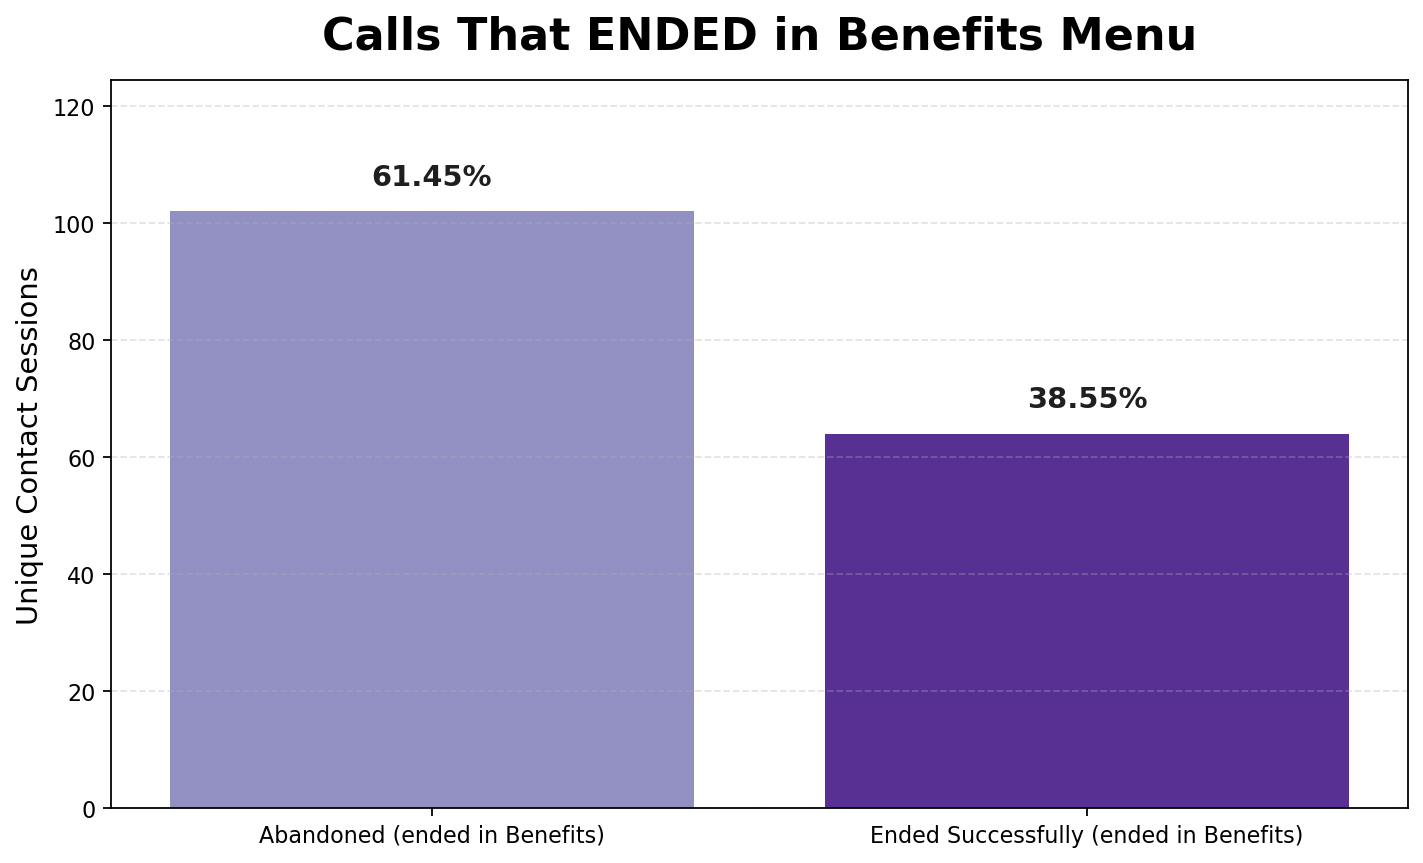

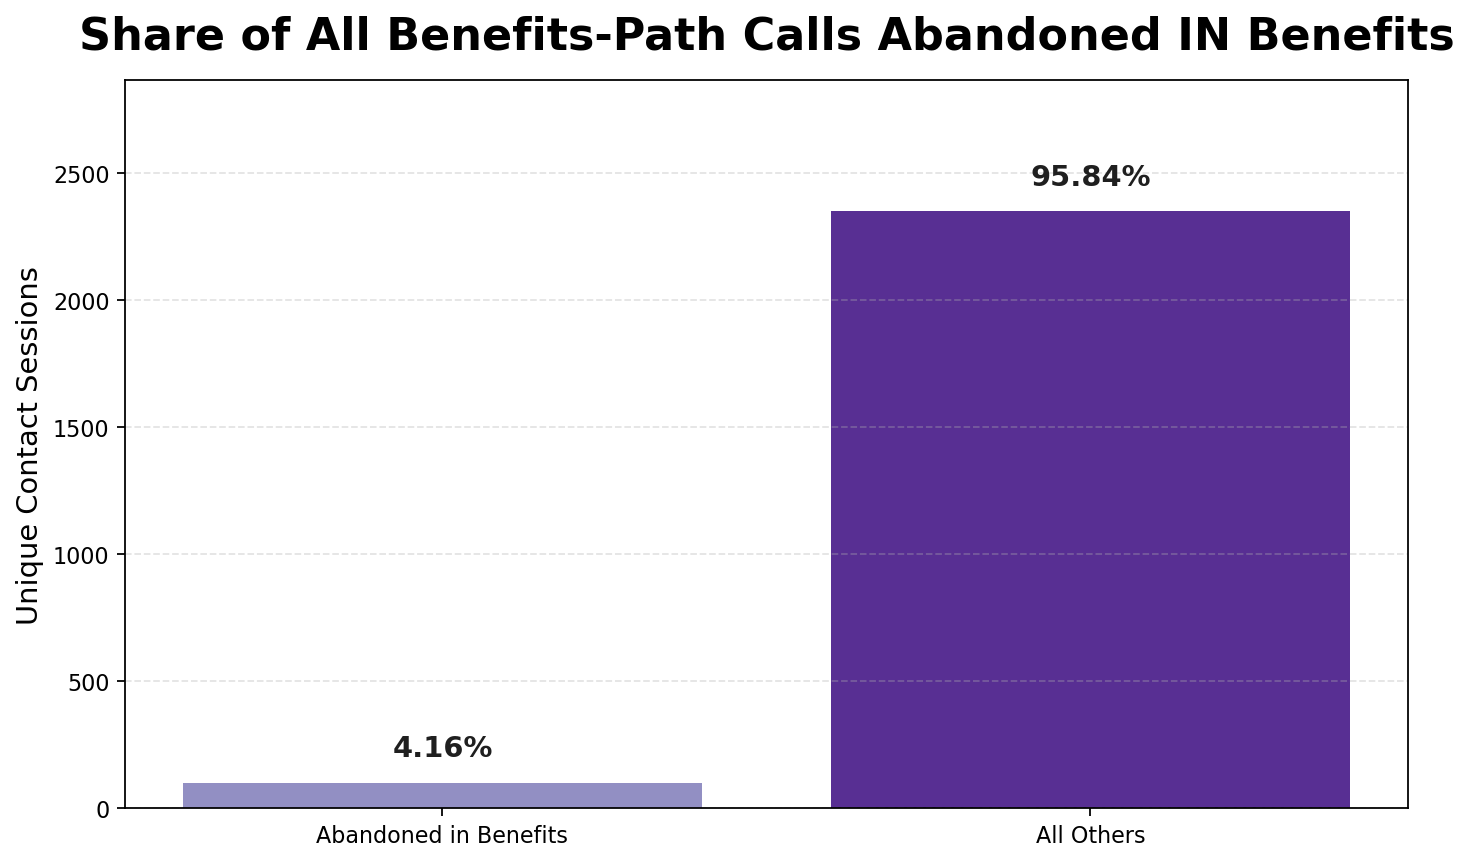

In [177]:
import numpy as np
import matplotlib.pyplot as plt

def draw_pct_bar(labels, counts, title, ylabel="Unique Contact Sessions", dpi=160):
    total = sum(counts)
    percents = [c / total * 100 for c in counts]
    max_count = max(counts)

    # two purple shades from the colormap (values in [0,1])
    colors = [plt.cm.Purples(0.55), plt.cm.Purples(0.85)]

    fig, ax = plt.subplots(figsize=(9, 5.5), dpi=dpi)
    bars = ax.bar(labels, counts, color=colors, edgecolor='none')

    ax.set_ylim(0, max_count * 1.22)  # headroom so labels never clip

    for bar, pct in zip(bars, percents):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + max_count * 0.035,
                f'{pct:.2f}%',
                ha='center', va='bottom',
                fontsize=13, fontweight='bold', color='#1f1f1f')

    ax.set_title(title, fontsize=20, fontweight='bold', pad=14)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    fig.tight_layout()
    return fig, ax

# 1) Calls that ENDED in Benefits: Abandoned vs Reached Agent
counts1 = [abandoned_end_count, reached_end_count]
labels1  = ['Abandoned (ended in Benefits)', 'Ended Successfully (ended in Benefits)']
draw_pct_bar(labels1, counts1, 'Calls That ENDED in Benefits Menu')
plt.show()

# 2) Of ALL calls that crossed Benefits, share abandoned IN Benefits
counts2 = [abandoned_end_count, total_crossed_benefits - abandoned_end_count]
labels2  = ['Abandoned in Benefits', 'All Others']
draw_pct_bar(labels2, counts2, 'Share of All Benefits-Path Calls Abandoned IN Benefits')
plt.show()
